In [2]:
import os
from typing import TypedDict, Annotated, List, Optional
from datetime import datetime

from langgraph.graph import StateGraph, END
from openai import OpenAI



# Initialize OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [ ]:
from services.doctor_service import get_specialities_list, get_doctor_info, generate_time_slots
from services.booking_service import get_available_slots, confirm_booking

In [3]:



class BookingState(TypedDict):
    """State for the booking conversation."""
    messages: Annotated[List[dict], lambda x, y: x + y]
    stage: str  # greeting, select_speciality, select_doctor, select_slot, confirm, completed
    selected_speciality: Optional[str]
    selected_doctor: Optional[dict]
    selected_slot: Optional[str]
    customer_name: Optional[str]
    customer_phone: Optional[str]
    booking_id: Optional[str]
    available_options: List[str]  # For clickable UI options


def create_initial_state():
    """Create initial state for the conversation."""
    return {
        "messages": [],
        "stage": "greeting",
        "selected_speciality": None,
        "selected_doctor": None,
        "selected_slot": None,
        "customer_name": None,
        "customer_phone": None,
        "booking_id": None,
        "available_options": []
    }


def llm_router(state: BookingState) -> str:
    """Use LLM to determine the next stage based on user input.
    
    This is the core routing function that uses LLM to understand user intent
    and route to the appropriate next stage.
    """
    current_stage = state["stage"]
    last_message = state["messages"][-1]["content"] if state["messages"] else ""
    
    # Define routing prompts based on current stage
    routing_prompts = {
        "greeting": """You are a routing assistant for a clinic booking system.
        Current stage: greeting
        User message: "{message}"
        
        Determine if the user wants to book an appointment or is greeting.
        Respond with ONLY one of these: "select_speciality" or "greeting"
        """,
        "select_speciality": """You are a routing assistant for a clinic booking system.
        Current stage: select_speciality
        Available specialities: General Physician, Dermatologist, Orthopedic, Pediatrician, ENT Specialist
        User message: "{message}"
        
        Determine which speciality the user selected, if any.
        Respond with ONLY one of these: "select_doctor" (if valid speciality mentioned), "select_speciality" (if unclear or invalid)
        """,
        "select_doctor": """You are a routing assistant for a clinic booking system.
        Current stage: select_doctor
        User message: "{message}"
        
        Determine if user wants to proceed with slot selection.
        Respond with ONLY one of these: "select_slot" or "select_doctor"
        """,
        "select_slot": """You are a routing assistant for a clinic booking system.
        Current stage: select_slot
        Available slots: {available_options}
        User message: "{message}"
        
        Determine if user selected a valid time slot.
        Respond with ONLY one of these: "confirm" (if valid slot), "select_slot" (if unclear or invalid)
        """,
        "confirm": """You are a routing assistant for a clinic booking system.
        Current stage: confirm
        User message: "{message}"
        
        Determine user's confirmation intent.
        Respond with ONLY one of these: "completed" (if confirmed), "cancelled" (if cancelled/rejected), "confirm" (if unclear)
        """
    }
    
    if current_stage not in routing_prompts:
        return current_stage
    
    prompt = routing_prompts[current_stage].format(
        message=last_message,
        available_options=", ".join(state.get("available_options", []))
    )
    
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a routing assistant. Respond with only the route name."},
                {"role": "user", "content": prompt}
            ],
            temperature=0,
            max_tokens=20
        )
        route = response.choices[0].message.content.strip().lower()
        
        # Validate route
        valid_routes = ["greeting", "select_speciality", "select_doctor", "select_slot", "confirm", "completed", "cancelled"]
        if route in valid_routes:
            return route
    except Exception as e:
        print(f"Routing error: {e}")
    
    return current_stage


def greeting_node(state: BookingState) -> BookingState:
    """Handle greeting stage."""
    specialities = get_specialities_list()
    
    message = """👋 Welcome to CarePlus Clinic!

I can help you book an appointment with one of our doctors.

Please choose a speciality:"""
    
    state["messages"].append({
        "role": "assistant",
        "content": message
    })
    state["available_options"] = specialities
    state["stage"] = "select_speciality"
    
    return state


def select_speciality_node(state: BookingState) -> BookingState:
    """Handle speciality selection."""
    last_message = state["messages"][-1]["content"] if state["messages"] else ""
    
    # Use LLM to extract speciality
    specialities = get_specialities_list()
    
    prompt = f"""Extract the medical speciality from this user message: "{last_message}"
    Available specialities: {', '.join(specialities)}
    
    Respond with ONLY the exact speciality name from the list, or "UNKNOWN" if not found.
    """
    
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You extract information from messages."},
                {"role": "user", "content": prompt}
            ],
            temperature=0,
            max_tokens=30
        )
        extracted = response.choices[0].message.content.strip()
        
        # Find matching speciality
        selected = None
        for spec in specialities:
            if spec.lower() in extracted.lower() or extracted.lower() in spec.lower():
                selected = spec
                break
        
        if selected:
            state["selected_speciality"] = selected
            state["stage"] = "select_doctor"
        else:
            # Invalid speciality, stay in this stage
            state["messages"].append({
                "role": "assistant",
                "content": "I didn't recognize that speciality. Please choose from: " + ", ".join(specialities)
            })
            state["available_options"] = specialities
    except Exception as e:
        print(f"Extraction error: {e}")
        state["messages"].append({
            "role": "assistant",
            "content": "Please choose a valid speciality: " + ", ".join(specialities)
        })
        state["available_options"] = specialities
    
    return state


def select_doctor_node(state: BookingState) -> BookingState:
    """Handle doctor selection and show available slots."""
    speciality = state["selected_speciality"]
    doctor = get_doctor_info(speciality)
    
    if not doctor:
        state["messages"].append({
            "role": "assistant",
            "content": "Sorry, no doctor available for that speciality. Please try another."
        })
        state["stage"] = "select_speciality"
        state["available_options"] = get_specialities_list()
        return state
    
    state["selected_doctor"] = doctor
    
    # Generate available slots
    slots = generate_time_slots(doctor["office_timing"])
    
    message = f"""You've selected {doctor['doctor_name']} ({doctor['speciality']}).
Office timing is from {doctor['office_timing']}.

Please select an available time slot:"""
    
    state["messages"].append({
        "role": "assistant",
        "content": message
    })
    state["available_options"] = slots
    state["stage"] = "select_slot"
    
    return state


def select_slot_node(state: BookingState) -> BookingState:
    """Handle time slot selection."""
    last_message = state["messages"][-1]["content"] if state["messages"] else ""
    doctor = state["selected_doctor"]
    
    # Use LLM to extract time slot
    available_slots = generate_time_slots(doctor["office_timing"])
    
    prompt = f"""Extract the time slot from this user message: "{last_message}"
    Available slots: {', '.join(available_slots)}
    
    Respond with ONLY the exact time slot from the list (e.g., "1:00 PM"), or "UNKNOWN" if not found.
    """
    
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You extract time slots from messages."},
                {"role": "user", "content": prompt}
            ],
            temperature=0,
            max_tokens=20
        )
        extracted = response.choices[0].message.content.strip()
        
        # Find matching slot
        selected = None
        for slot in available_slots:
            if slot.lower() in extracted.lower():
                selected = slot
                break
        
        if selected:
            state["selected_slot"] = selected
            state["stage"] = "confirm"
        else:
            state["messages"].append({
                "role": "assistant",
                "content": "Please select a valid time slot: " + ", ".join(available_slots)
            })
            state["available_options"] = available_slots
    except Exception as e:
        print(f"Slot extraction error: {e}")
        state["messages"].append({
            "role": "assistant",
            "content": "Please select a valid time slot: " + ", ".join(available_slots)
        })
        state["available_options"] = available_slots
    
    return state


def confirm_node(state: BookingState) -> BookingState:
    """Handle confirmation stage."""
    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    
    message = f"""Please review your appointment details:

**Doctor:** {doctor['doctor_name']}
**Speciality:** {doctor['speciality']}
**Time:** Today at {slot}

Would you like to confirm this appointment?"""
    
    state["messages"].append({
        "role": "assistant",
        "content": message
    })
    state["available_options"] = ["Confirm", "Cancel"]
    
    return state


def completed_node(state: BookingState) -> BookingState:
    """Handle completed booking."""
    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    
    # Generate a simple booking ID (in real app, use proper customer info)
    booking_id = f"BKG-{datetime.now().strftime('%H%M%S')}"
    
    message = f"""✅ Appointment Confirmed!

**Booking ID:** {booking_id}
**Doctor:** {doctor['doctor_name']}
**Time:** Today at {slot}

Thank you for choosing CarePlus Clinic. Please arrive 15 minutes before your appointment."""
    
    state["messages"].append({
        "role": "assistant",
        "content": message
    })
    state["booking_id"] = booking_id
    state["available_options"] = []
    
    return state


def cancelled_node(state: BookingState) -> BookingState:
    """Handle cancelled booking."""
    state["messages"].append({
        "role": "assistant",
        "content": "Your appointment has been cancelled. If you'd like to book again, just let me know!"
    })
    state["available_options"] = ["Book Again"]
    state["stage"] = "greeting"
    
    return state







In [4]:
def build_booking_graph():
    """Build and compile the LangGraph for booking flow."""
    workflow = StateGraph(BookingState)
    
    # Add nodes
    workflow.add_node("greeting", greeting_node)
    workflow.add_node("select_speciality", select_speciality_node)
    workflow.add_node("select_doctor", select_doctor_node)
    workflow.add_node("select_slot", select_slot_node)
    workflow.add_node("confirm", confirm_node)
    workflow.add_node("completed", completed_node)
    workflow.add_node("cancelled", cancelled_node)
    
    # Add conditional edges with LLM routing
    workflow.add_conditional_edges(
        "greeting",
        llm_router,
        {
            "greeting": "greeting",
            "select_speciality": "select_speciality"
        }
    )
    
    workflow.add_conditional_edges(
        "select_speciality",
        llm_router,
        {
            "select_speciality": "select_speciality",
            "select_doctor": "select_doctor"
        }
    )
    
    workflow.add_conditional_edges(
        "select_doctor",
        llm_router,
        {
            "select_doctor": "select_doctor",
            "select_slot": "select_slot"
        }
    )
    
    workflow.add_conditional_edges(
        "select_slot",
        llm_router,
        {
            "select_slot": "select_slot",
            "confirm": "confirm"
        }
    )
    
    workflow.add_conditional_edges(
        "confirm",
        llm_router,
        {
            "confirm": "confirm",
            "completed": "completed",
            "cancelled": "cancelled"
        }
    )
    
    # Set entry point
    workflow.set_entry_point("greeting")
    
    # Compile
    return workflow.compile()


# Create the compiled graph
booking_graph = build_booking_graph()

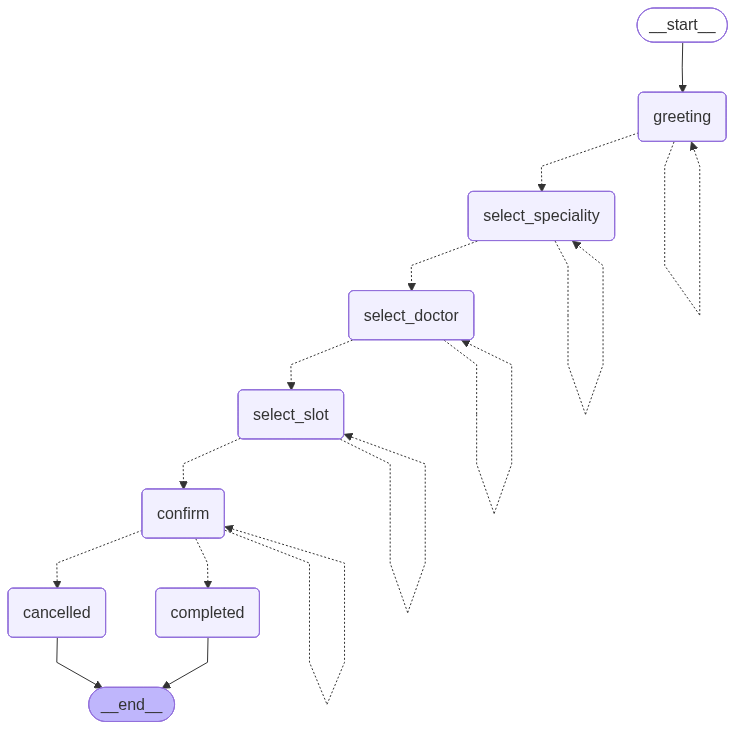

In [6]:
from IPython.display import Image, display

png_bytes = booking_graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

In [7]:
def process_message(state: BookingState, user_message: str) -> BookingState:
    """Process a user message through the booking graph."""
    # Add user message to state
    state["messages"].append({
        "role": "user",
        "content": user_message
    })
    
    # Run the graph
    result = booking_graph.invoke(state)
    
    return result